# Lab Instructions

Find a dataset that interests you. I'd recommend starting on [Kaggle](https://www.kaggle.com/). Read through all of the material about the dataset and download a .CSV file.

1. Write a short summary of the data.  Where did it come from?  How was it collected?  What are the features in the data?  Why is this dataset interesting to you?  

2. Identify 5 interesting questions about your data that you can answer using Pandas methods.  

3. Answer those questions!  You may use any method you want (including LLMs) to help you write your code; however, you should use Pandas to find the answers.  LLMs will not always write code in this way without specific instruction.  

4. Write the answer to your question in a text box underneath the code you used to calculate the answer.



I am using a dataset of Movies and TV Shows from Netflix that can be found here: https://www.kaggle.com/datasets/rahulvyasm/netflix-movies-and-tv-shows

1.) This data comes from Kaggle.com, and appears to have been collected directly from Netflix's own catalogues. This dataset has titles, directors, origin country, durations, ratings, the date added, and a few other usefull things. I chose this dataset because, like many people nowadays, I enjoy watching movies and TV!

2.) Some interesting questions.
* What percentage of movies and TV shows originated from outside of the US?
* Say a user is 16 years old, according to the ratings what percentage of shows and movies would they be able to actually watch?
* What is the distribution of TV shows to Movies?
* How many things were added every year, and what was the most productive year?
* What is the most common duration of TV shows?

In [1]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv', encoding='latin-1')
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
filtered_df = df.loc[(df['duration'] == '17 Seasons')]
filtered_df.head(25)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
548,s549,TV Show,Grey's Anatomy,NaN,"Ellen Pompeo, Sandra Oh, Katherine Heigl, Just...",United States,"July 3, 2021",2020,TV-14,17 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Distribution of Country'}>

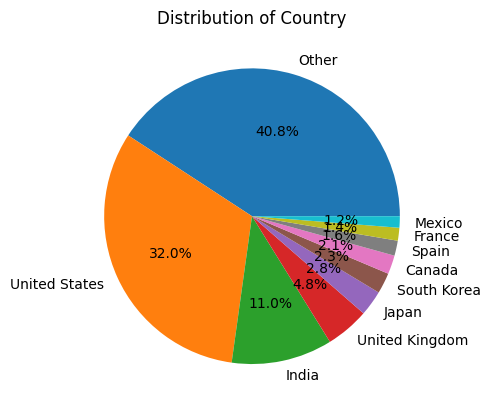

In [3]:
top_9 = df['country'].value_counts().head(9)
all_country = df['country'].fillna('Other').apply(lambda c: c if c in top_9 else 'Other')

all_country.value_counts().plot(kind='pie', title='Distribution of Country', autopct='%1.1f%%')

68% of shows originate from outside of the US.

<Axes: title={'center': 'Distribution of Ratings'}>

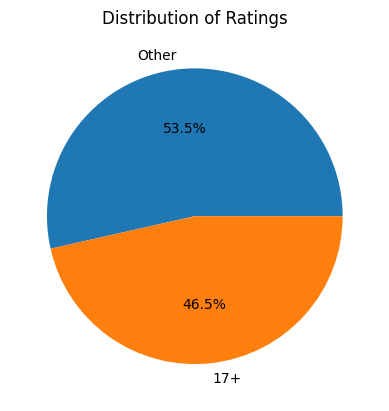

In [4]:
adult_ratings = {'TV-MA', 'R', 'A', 'UR', 'NR', 'NC-17'}
grouped_ratings = df['rating'].fillna('Other').apply(lambda r: '17+' if r in adult_ratings else 'Other')

grouped_ratings.value_counts().plot(kind='pie', title='Distribution of Ratings', autopct='%1.1f%%')

53.5% of content is available to users under 17 years old according to TV/Movie ratings.

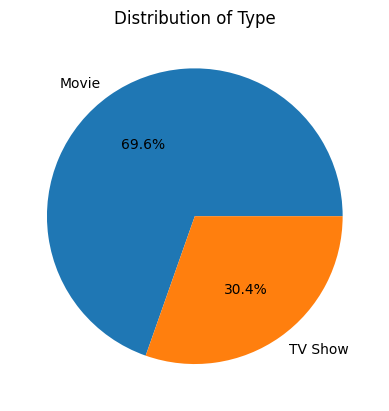

In [5]:
show_Dist = df['type'].value_counts().plot(kind='pie', title='Distribution of Type', autopct='%1.1f%%')

30.4% of content is TV Shows, and 69.6% of content is Movies.

count    8809.000000
mean     2014.181292
std         8.818932
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2024.000000
Name: release_year, dtype: float64

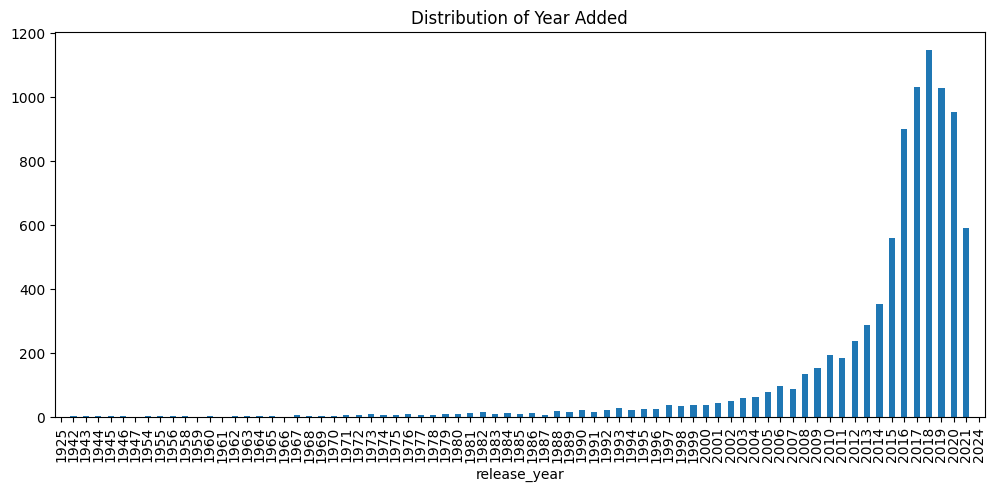

In [6]:
year_dist = df['release_year'].value_counts().sort_index().plot(kind='bar', title='Distribution of Year Added', figsize=(12, 5))
df['release_year'].describe()

2018 was the most productive year, ramping up steadily (For original release dates) from as early as 1925!
Pioneers: First Women Filmmakers* is a collection of restored films made by women, which has a date of 1925.

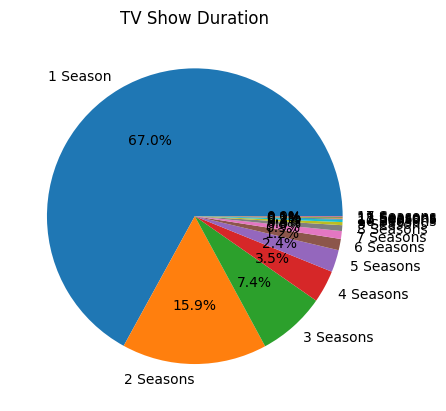

In [7]:
# Filter TV shows and extract duration
TV_shows = df[df['type'] == 'TV Show']
TV_duration_Season = TV_shows['duration'].value_counts().plot(kind='pie', title='TV Show Duration', autopct='%1.1f%%')

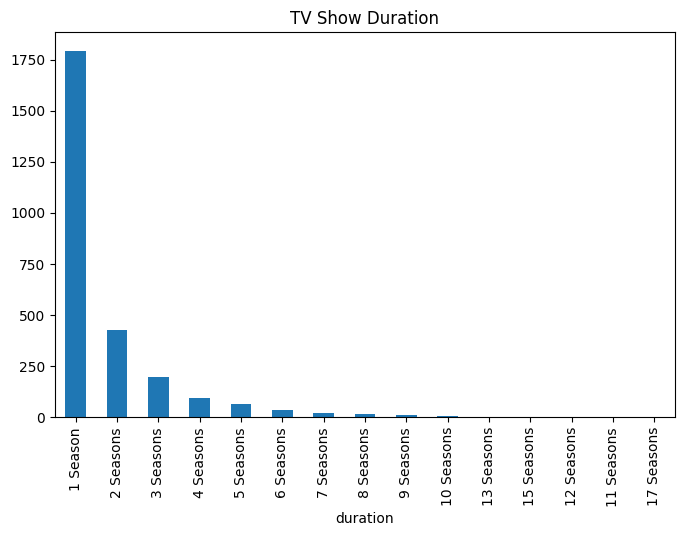

In [8]:
TV_duration_Season = TV_shows['duration'].value_counts().plot(kind='bar', title='TV Show Duration', figsize=(8, 5))

67% of TV Shows only last for one season, and one show spans for 17 whole seasons(Greys Anatomy)!